In [1]:
import netCDF4 as nc
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
fn = 'SeaSurfaceTemperature_monthly_187001-202402.nc'
sst_data = nc.Dataset(fn)
lon = sst_data['longitude'][:]
lat = sst_data['latitude'][:]
sst = sst_data['sst'][:]
sst.mask[sst == -1000] = True

# verify dimensions
time = sst_data['time'][:]
print(f"lon shape: {lon.shape}")
print(f"lat shape: {lat.shape}")
print(f"sst shape: {sst.shape}")

# Count valid points (non-masked)
valid_count = (~sst.mask).sum()

# X will have one row per valid point and one column per dimension in (time, lat, lon)
X_shape = (valid_count, len(sst.shape))  # len(sst.shape) = number of dimensions
y_shape = (valid_count,)                 # one value per valid point

print("Original X shape:", X_shape)
print("Original y shape:", y_shape)

# checking with examples to see if sst[i,j,k] corresponds to (time[i], lat[j], lon[k])
i, j, k = 5, 11, 7
print(f"Example sst[{i},{j},{k}] =", sst[i, j, k].item(),
      f"at time={time[i]}, lat={lat[j]}, lon={lon[k]}")

lon shape: (360,)
lat shape: (180,)
sst shape: (1850, 180, 360)
Original X shape: (np.int64(77582832), 3)
Original y shape: (np.int64(77582832),)
Example sst[5,11,7] = -1.7999999523162842 at time=166.0, lat=78.5, lon=-172.5


In [3]:
try:
    t_units = sst_data['time'].units
    t_cal = getattr(sst_data['time'], 'calendar', 'standard')
    t_dates = nc.num2date(time, units=t_units, calendar=t_cal)
    time_index = pd.to_datetime(t_dates)
except Exception:
    # Fallback: assume monthly cadence from 1870-01
    time_index = pd.date_range('1870-01-01', periods=len(time), freq='MS')

print(f"Time span: {time_index.min().date()} → {time_index.max().date()} "
      f"({len(time_index)} months)")

n_samples=9000000

# build X, y
def sample_X_y_masked(sst_masked, time_vals, lat_vals, lon_vals, n_samples, seed=7):

    # X[m,:] = (time_value, latitude, longitude), y[m] = SST (°C), ignoring masked (land/invalid)
    rng = np.random.default_rng(seed)
    T = len(time_vals)
    t_idx = rng.integers(0, T, size=n_samples)

    j_idx = np.empty(n_samples, dtype=np.int32)
    k_idx = np.empty(n_samples, dtype=np.int32)
    y     = np.empty(n_samples, dtype=np.float32)

    for t in np.unique(t_idx):
        sel = np.where(t_idx == t)[0]
        sst2d = sst_masked[t, :, :].filled(np.nan) # 2-D slice; convert masked to NaN to build valid mask
        valid = np.isfinite(sst2d)                 # masked values are now NaN
        if not np.any(valid):
            t_idx[sel] = rng.integers(0, T, size=len(sel))
            continue
        jj, kk = np.where(valid)
        pick = rng.integers(0, len(jj), size=len(sel))
        j_idx[sel] = jj[pick]
        k_idx[sel] = kk[pick]
        y[sel] = sst2d[j_idx[sel], k_idx[sel]]

    X = np.column_stack([time_vals[t_idx], lat_vals[j_idx], lon_vals[k_idx]]).astype(np.float32)
    return X, y

X_all, y_all = sample_X_y_masked(sst, time, lat, lon, n_samples, seed=7)
print("Sampled dataset:", X_all.shape, y_all.shape)

Time span: 1870-01-01 → 2024-02-01 (1850 months)
Sampled dataset: (9000000, 3) (9000000,)


---

In [4]:
# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.3, random_state=7
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=7
)

print(f"Split sizes → train = {len(X_train)}, val = {len(X_val)}, test = {len(X_test)}")

Split sizes → train = 6300000, val = 1350000, test = 1350000


---

In [5]:
alphas  = np.linspace(0.01, 1, 50)
degrees = [1, 2, 3, 4]

records = []
best_model = None
best_cfg   = None
best_val_mse = np.inf

for deg in degrees:
    for a in alphas:
        model = Pipeline([
            ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
            ('scaler', StandardScaler()),
            ('ridge',  Ridge(alpha=a))
        ])
        model.fit(X_train, y_train)

        yhat_tr  = model.predict(X_train)
        yhat_val = model.predict(X_val)

        rec = {
            'degree':   deg,
            'alpha':    float(a),
            'train_mse': float(mean_squared_error(y_train, yhat_tr)),
            'train_mae': float(mean_absolute_error(y_train, yhat_tr)),
            'val_mse':   float(mean_squared_error(y_val, yhat_val)),
            'val_mae':   float(mean_absolute_error(y_val, yhat_val)),
        }
        records.append(rec)

        if rec['val_mse'] < best_val_mse:
            best_val_mse = rec['val_mse']
            best_model   = model
            best_cfg     = {'degree': deg, 'alpha': float(a)}


print("Best configuration:", best_cfg, "with validation MSE =", best_val_mse)
err_df = pd.DataFrame.from_records(records).sort_values(['degree','alpha'])
err_df

Best configuration: {'degree': 4, 'alpha': 0.4342857142857143} with validation MSE = 6.577936172485352


,degree,alpha,train_mse,train_mae,val_mse,val_mae
0,1,0.010000,127.379379,10.244491,127.379745,10.244722
1,1,0.030204,127.379379,10.244491,127.379745,10.244722
2,1,0.050408,127.379379,10.244491,127.379745,10.244722
3,1,0.070612,127.379379,10.244491,127.379745,10.244722
4,1,0.090816,127.379379,10.244491,127.379745,10.244722
...,...,...,...,...,...,...
195,4,0.919184,6.574168,1.896367,6.577936,1.896164
196,4,0.939388,6.574167,1.896367,6.577936,1.896164
197,4,0.959592,6.574168,1.896367,6.577936,1.896164
198,4,0.979796,6.574168,1.896367,6.577937,1.896164


---

Selected best hyperparameters (global): {'degree': 4, 'alpha': 0.4342857142857143}


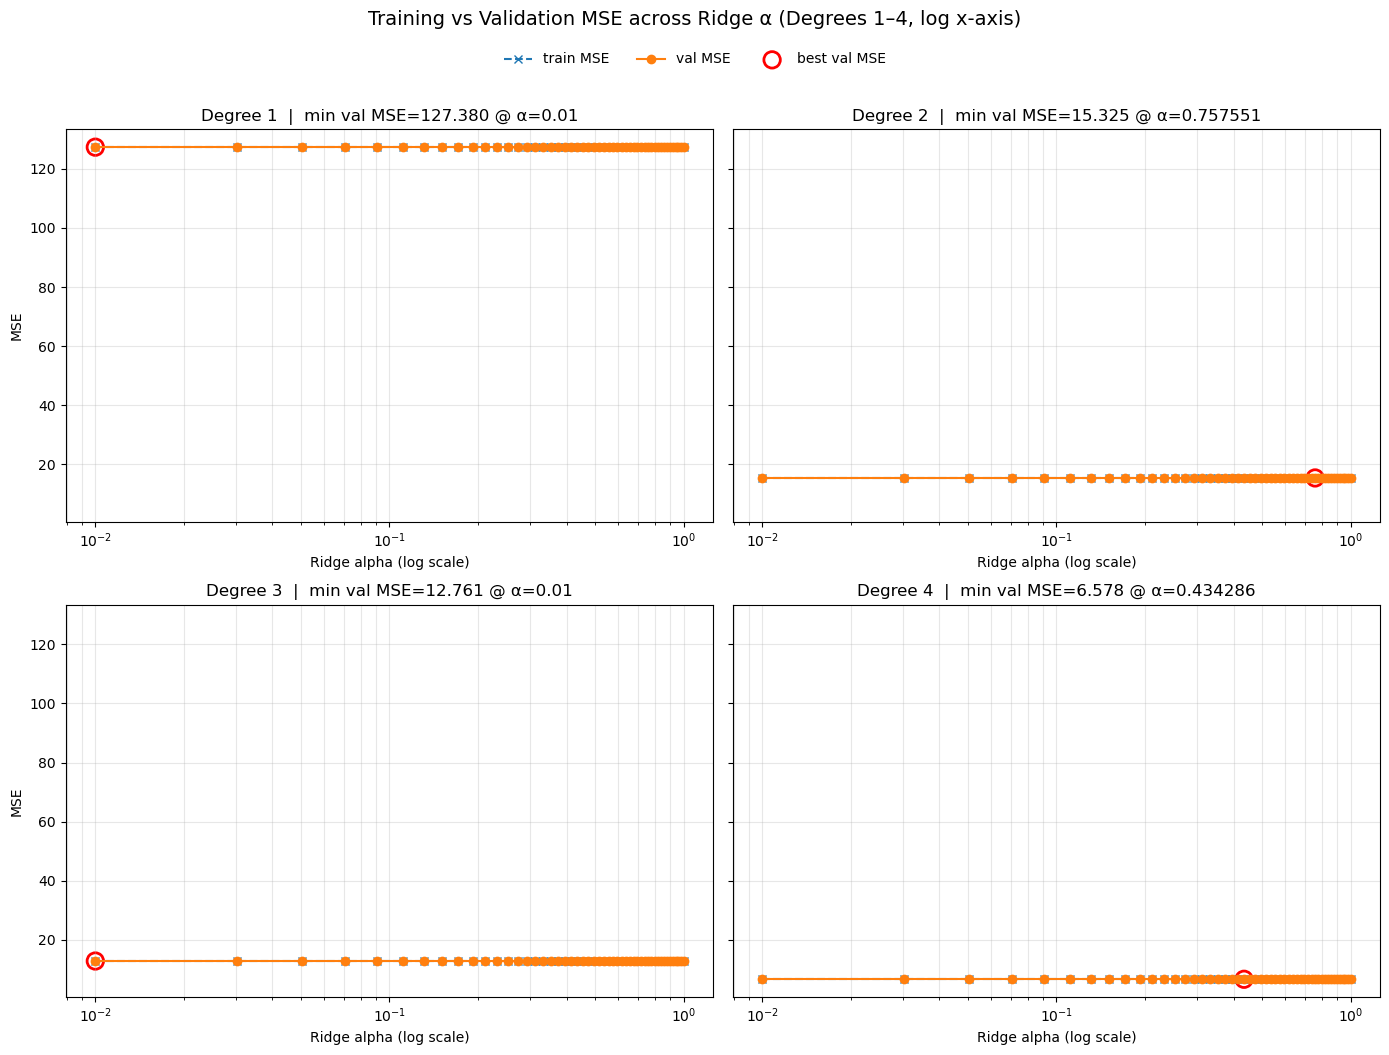

In [6]:
print("Selected best hyperparameters (global):", best_cfg)

# set y-limits
ymin = err_df[['train_mse', 'val_mse']].min().min()
ymax = err_df[['train_mse', 'val_mse']].max().max()
pad  = 0.05 * (ymax - ymin) if ymax > ymin else 0.5

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.ravel()

for idx, deg in enumerate(sorted(err_df['degree'].unique())):
    ax  = axes[idx]
    sub = err_df[err_df['degree'] == deg].sort_values('alpha')
    
    ax.semilogx(sub['alpha'], sub['train_mse'], marker='x', linestyle='--', label='train MSE')
    ax.semilogx(sub['alpha'], sub['val_mse'],   marker='o', linestyle='-',  label='val MSE')

    # best alpha for this degree (min val MSE)
    i_best = int(np.argmin(sub['val_mse'].to_numpy()))
    a_best = sub['alpha'].iloc[i_best]
    v_best = sub['val_mse'].iloc[i_best]

    # mark best on the log x-axis
    ax.scatter(a_best, v_best, s=140, facecolors='none',
               edgecolors='red', linewidths=2, label='best val MSE')

    ax.set_xlabel('Ridge alpha (log scale)')
    ax.set_ylabel('MSE' if idx in (0, 2) else '')
    ax.set_title(f'Degree {deg}  |  min val MSE={v_best:.3f} @ α={a_best:g}')
    ax.grid(True, which='both', alpha=0.3)
    ax.set_ylim(ymin - pad, ymax + pad)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))

fig.suptitle('Training vs Validation MSE across Ridge α (Degrees 1–4, log x-axis)',
             y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

Degree 1  |  min val MSE=127.380 @ α=0.01
Degree 2  |  min val MSE=15.325 @ α=0.757551
Degree 3  |  min val MSE=12.761 @ α=0.01
Degree 4  |  min val MSE=6.578 @ α=0.434286


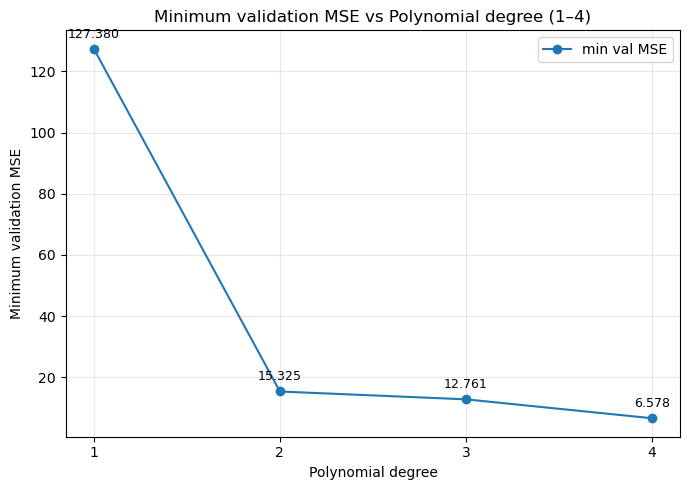

In [7]:
best_rows = (
    err_df.loc[err_df.groupby('degree')['val_mse'].idxmin()]
          .sort_values('degree')
)

for _, row in best_rows.iterrows():
    deg    = int(row['degree'])
    v_best = float(row['val_mse'])
    a_best = float(row['alpha'])
    print(f"Degree {deg}  |  min val MSE={v_best:.3f} @ α={a_best:g}")

deg_list  = best_rows['degree'].astype(int).to_numpy()
mse_list  = best_rows['val_mse'].to_numpy()

plt.figure(figsize=(7, 5))
plt.plot(deg_list, mse_list, marker='o', linestyle='-', color='tab:blue', label='min val MSE')
for d, m in zip(deg_list, mse_list):
    plt.annotate(f"{m:.3f}", (d, m), textcoords="offset points", xytext=(0,8), ha='center', fontsize=9)

plt.xticks([1, 2, 3, 4])
plt.xlabel('Polynomial degree')
plt.ylabel('Minimum validation MSE')
plt.title('Minimum validation MSE vs Polynomial degree (1–4)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

---

Test MSE=6.591522216796875, MAE=1.8993910551071167


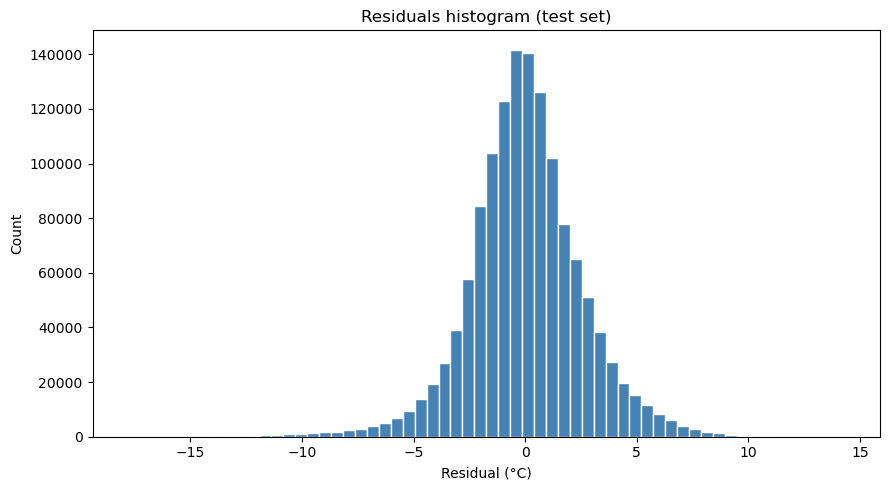

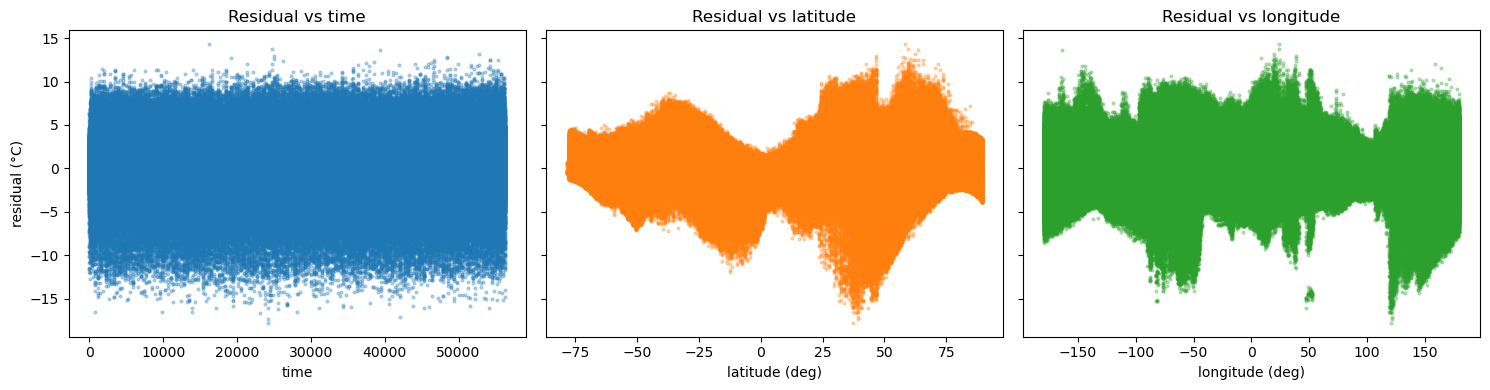

Nearest grid to Hong Kong: lat=22.5, lon=114.5


C:\Users\lauyu\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


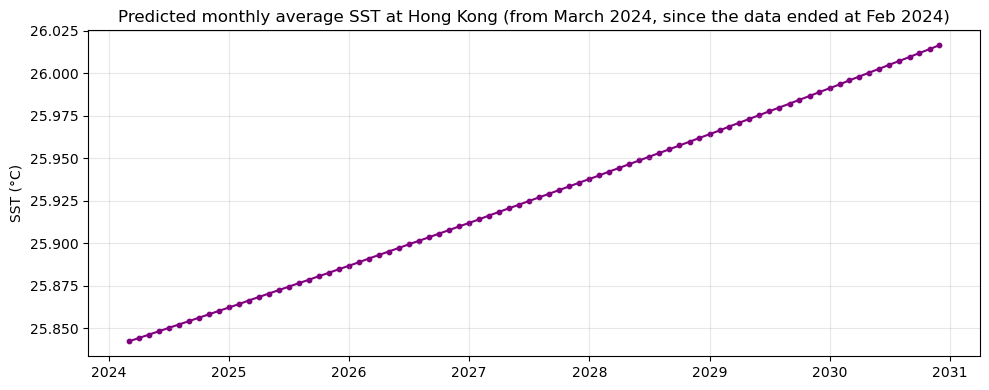

      date  sst_pred_degC
2024-03-01      25.842087
2024-04-01      25.844074
2024-05-01      25.846062
2024-06-01      25.848057
2024-07-01      25.850052
2024-08-01      25.852055
2024-09-01      25.854057
2024-10-01      25.856064
2024-11-01      25.858078
2024-12-01      25.860096
2025-01-01      25.862114
2025-02-01      25.864141
2025-03-01      25.866171
2025-04-01      25.868202
2025-05-01      25.870239
2025-06-01      25.872280
2025-07-01      25.874329
2025-08-01      25.876377
2025-09-01      25.878431
2025-10-01      25.880486
2025-11-01      25.882545
2025-12-01      25.884615
2026-01-01      25.886684
2026-02-01      25.888760
2026-03-01      25.890837
2026-04-01      25.892921
2026-05-01      25.895004
2026-06-01      25.897097
2026-07-01      25.899193
2026-08-01      25.901291
2026-09-01      25.903393
2026-10-01      25.905500
2026-11-01      25.907612
2026-12-01      25.909733
2027-01-01      25.911848
2027-02-01      25.913975
2027-03-01      25.916103
2027-04-01  

In [8]:
yhat_test = best_model.predict(X_test)
test_mse  = mean_squared_error(y_test, yhat_test)
test_mae  = mean_absolute_error(y_test, yhat_test)
print(f"Test MSE={test_mse}, MAE={test_mae}")

resid = y_test - yhat_test

plt.figure(figsize=(9, 5))
plt.hist(resid, bins=60, color='steelblue', edgecolor='white')
plt.xlabel('Residual (°C)')
plt.ylabel('Count')
plt.title('Residuals histogram (test set)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
axes[0].scatter(X_test[:, 0], resid, s=4, alpha=0.3)
axes[0].set_xlabel('time'); axes[0].set_ylabel('residual (°C)'); axes[0].set_title('Residual vs time')
axes[1].scatter(X_test[:, 1], resid, s=4, alpha=0.3, color='tab:orange')
axes[1].set_xlabel('latitude (deg)'); axes[1].set_title('Residual vs latitude')
axes[2].scatter(X_test[:, 2], resid, s=4, alpha=0.3, color='tab:green')
axes[2].set_xlabel('longitude (deg)'); axes[2].set_title('Residual vs longitude')
plt.tight_layout()
plt.show()

# monthly SST at Hong Kong (22.32N, 114.16E) to Dec-2030
HK_lat, HK_lon = 22.32, 114.16
nearest_lat = lat[np.argmin(np.abs(lat - HK_lat))]
nearest_lon = lon[np.argmin(np.abs(lon - HK_lon))]
print(f"Nearest grid to Hong Kong: lat={nearest_lat}, lon={nearest_lon}")

# build future numeric time values
dt = np.median(np.diff(time)) if len(time) > 1 else 1
last_time_val = time[-1]

start_date = (time_index.max() + pd.offsets.MonthBegin(1)).normalize()
end_date   = pd.Timestamp('2030-12-01')
future_dates = pd.date_range(start_date, end_date, freq='MS')
future_time_vals = last_time_val + dt * np.arange(1, len(future_dates) + 1)

X_future = np.column_stack([
    future_time_vals,
    np.full(len(future_dates), nearest_lat, dtype=np.float32),
    np.full(len(future_dates), nearest_lon, dtype=np.float32)
]).astype(np.float32)

hk_pred = best_model.predict(X_future)

# forcast plot
plt.figure(figsize=(10, 4))
plt.plot(future_dates, hk_pred, color='purple')
plt.scatter(future_dates, hk_pred, s=10, color='purple')
plt.ylabel('SST (°C)')
plt.title('Predicted monthly average SST at Hong Kong (from March 2024, since the data ended at Feb 2024)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


df_forecast = pd.DataFrame({'date': future_dates, 'sst_pred_degC': hk_pred})
df_forecast['sst_pred_degC'] = df_forecast['sst_pred_degC']


with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df_forecast.to_string(index=False))